# Assignment 15 — LightGBM and XGBoost on Diabetes


## Objective

The objective is to compare the performance of LightGBM and XGBoost algorithms using the diabetes dataset.

## Data Loading


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV,cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

df=pd.read_csv("diabetes (1).csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Exploratory Data Analysis


(768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
Missing:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicates: 0


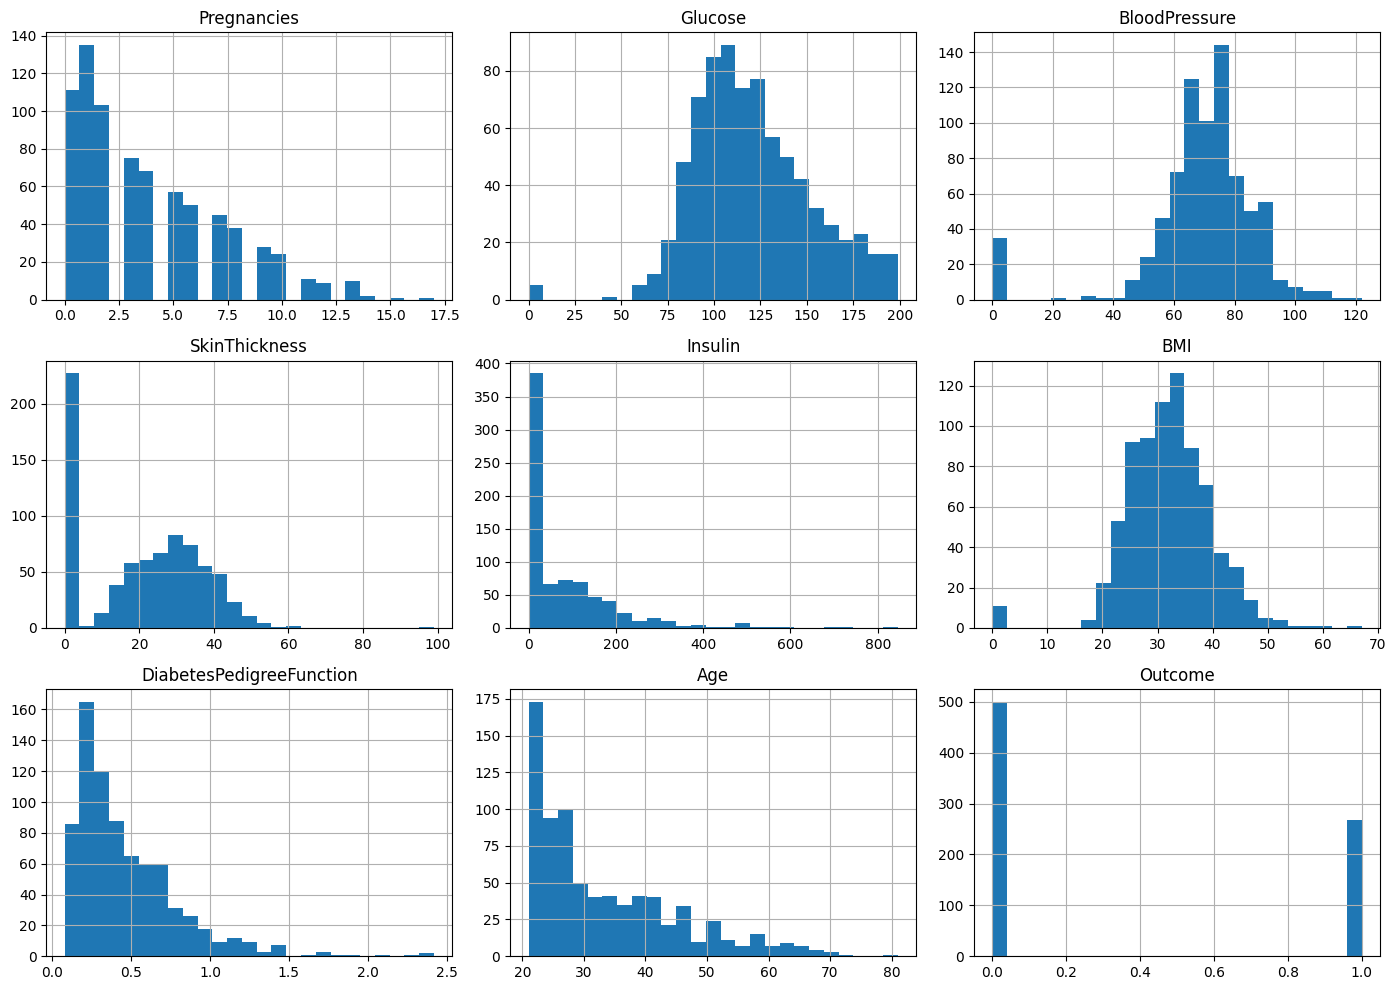

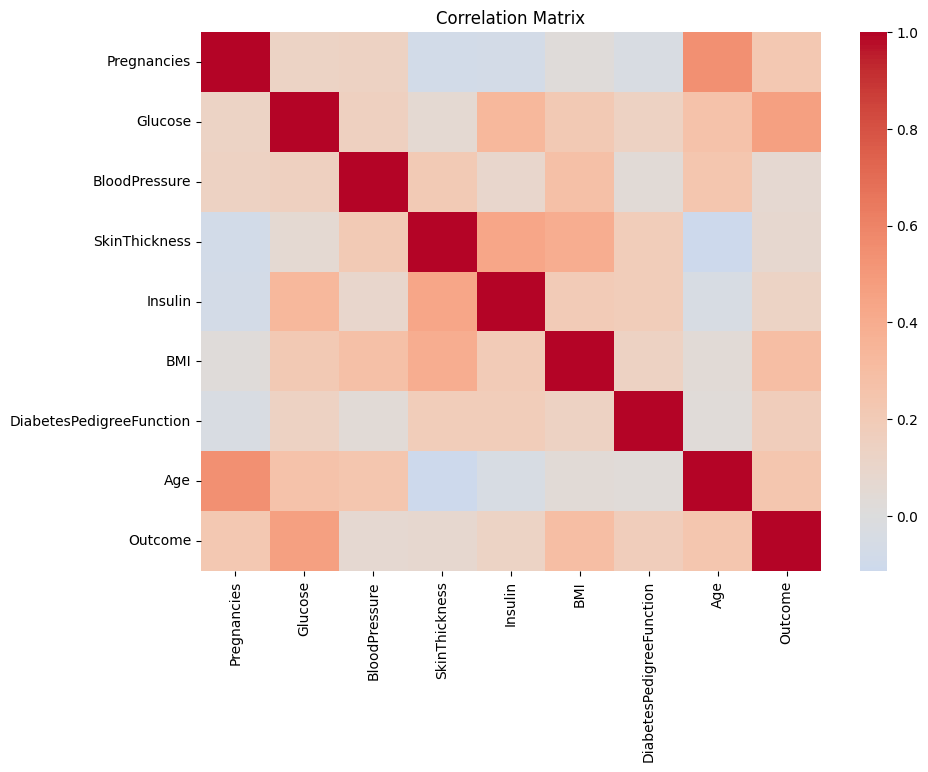

Outcome distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


In [2]:
print(df.shape); print(df.dtypes); print("Missing:\n",df.isna().sum()); print("Duplicates:",df.duplicated().sum())
df.hist(figsize=(14,10),bins=25); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,7)); sns.heatmap(df.corr(),cmap="coolwarm",center=0); plt.title("Correlation Matrix"); plt.show()
print("Outcome distribution:\n",df["Outcome"].value_counts())


## Data Preprocessing


In [3]:
X=df.drop(columns=["Outcome"]).copy(); y=df["Outcome"]
# In this dataset, zero values in selected medical measurements are treated as missing and imputed.
zero_missing=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
X[zero_missing]=X[zero_missing].replace(0,np.nan)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=42,stratify=y)

pipe_lgb=Pipeline([("imputer",SimpleImputer(strategy="median")),("model",LGBMClassifier(random_state=42,verbosity=-1))])
pipe_xgb=Pipeline([("imputer",SimpleImputer(strategy="median")),("model",XGBClassifier(random_state=42,eval_metric="logloss",n_estimators=250,max_depth=4,learning_rate=.05))])

def metrics(model):
    pred=model.predict(X_test)
    return {"Accuracy":accuracy_score(y_test,pred),"Precision":precision_score(y_test,pred,zero_division=0),"Recall":recall_score(y_test,pred,zero_division=0),"F1":f1_score(y_test,pred,zero_division=0)}

pipe_lgb.fit(X_train,y_train); pipe_xgb.fit(X_train,y_train)
base=pd.DataFrame({"LightGBM":metrics(pipe_lgb),"XGBoost":metrics(pipe_xgb)}).T
base


,Accuracy,Precision,Recall,F1
LightGBM,0.759740,0.666667,0.629630,0.647619
XGBoost,0.746753,0.653061,0.592593,0.621359


## Model Evaluation



 LightGBM
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.63      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154


 XGBoost
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



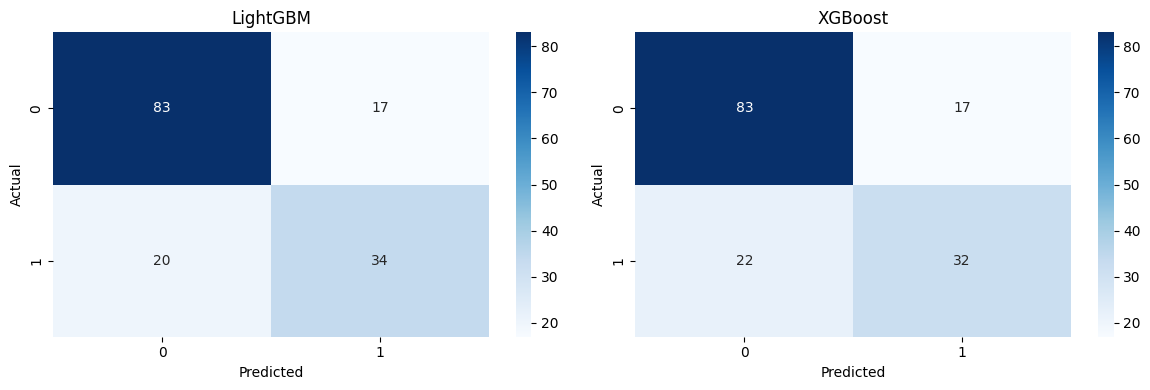

In [4]:
for name,model in [("LightGBM",pipe_lgb),("XGBoost",pipe_xgb)]:
    pred=model.predict(X_test)
    print("\n",name)
    print(classification_report(y_test,pred,zero_division=0))

fig,ax=plt.subplots(1,2,figsize=(12,4))
for a,(name,model) in zip(ax,[("LightGBM",pipe_lgb),("XGBoost",pipe_xgb)]):
    cm=confusion_matrix(y_test,model.predict(X_test)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=a); a.set_title(name); a.set_xlabel("Predicted"); a.set_ylabel("Actual")
plt.tight_layout(); plt.show()


## Hyperparameter Tuning and Cross-Validation


In [5]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
lgb_grid={"model__n_estimators":[100,200],"model__max_depth":[-1,4,6],"model__learning_rate":[.03,.05,.1]}
xgb_grid={"model__n_estimators":[100,200],"model__max_depth":[3,5],"model__learning_rate":[.03,.1]}

lgb_search=GridSearchCV(pipe_lgb,lgb_grid,cv=cv,scoring="f1",n_jobs=1); lgb_search.fit(X_train,y_train)
xgb_search=GridSearchCV(pipe_xgb,xgb_grid,cv=cv,scoring="f1",n_jobs=1); xgb_search.fit(X_train,y_train)
print("Best LightGBM:",lgb_search.best_params_,"CV F1:",lgb_search.best_score_)
print("Best XGBoost:",xgb_search.best_params_,"CV F1:",xgb_search.best_score_)
tuned=pd.DataFrame({"LightGBM":metrics(lgb_search.best_estimator_),"XGBoost":metrics(xgb_search.best_estimator_)}).T
tuned


Best LightGBM: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100} CV F1: 0.6372007870983103
Best XGBoost: {'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__n_estimators': 200} CV F1: 0.6388227913333782


,Accuracy,Precision,Recall,F1
LightGBM,0.759740,0.680851,0.592593,0.633663
XGBoost,0.766234,0.695652,0.592593,0.640000


## Comparative Analysis


In [6]:
comparison=base.add_prefix("Base_").join(tuned.add_prefix("Tuned_"))
comparison

best="LightGBM" if tuned.loc["LightGBM","F1"]>=tuned.loc["XGBoost","F1"] else "XGBoost"
print("Best tuned model by test F1:",best)


Best tuned model by test F1: XGBoost


## Conclusion


In [7]:
print("LightGBM and XGBoost were trained and tuned on the diabetes classification dataset. Missing values were handled through median imputation after treating impossible zero measurements as missing for selected variables. Cross-validated grid search was used for model optimization, and the final comparison considered accuracy, precision, recall, and F1-score. The tuned model with the stronger F1-score provides the preferred classification performance for this dataset.")


LightGBM and XGBoost were trained and tuned on the diabetes classification dataset. Missing values were handled through median imputation after treating impossible zero measurements as missing for selected variables. Cross-validated grid search was used for model optimization, and the final comparison considered accuracy, precision, recall, and F1-score. The tuned model with the stronger F1-score provides the preferred classification performance for this dataset.
